<a href="https://colab.research.google.com/github/Gbelsalvador/NLP-JEPA/blob/main/modele.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# librairis

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import defaultdict
import random
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [ ]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
dataset = [
    {"fr": "je mange une pomme"},
    {"fr": "le chat dort sur le canape"},
    {"fr": "il fait beau aujourd'hui"},
    {"fr": "je bois du café"},
    {"fr": "la voiture est rouge"},
    {"fr": "les enfants jouent dans le parc"},
    {"fr": "je lis un livre interresant"},
    {"fr": "le chien aboie fort"},
    {"fr": "elle ecrit une lettre"},
    {"fr": "le soleil brille dans le ciel"},
  {
    "fr": "Elle peut être donc définie soit comme un ensemble de connaissances, soit comme une méthode."
  },
  {
    "fr": "La science a pour objet de comprendre et d'expliquer le monde et ses phénomènes au départ de la connaissance, dans le but d'en tirer des prévisions et des applications fonctionnelles."
  },
  {
    "fr": "Elle se veut ouverte à la critique tant au niveau des connaissances acquises, des méthodes utilisées pour les acquérir et de l'argumentation utilisée lors de la recherche scientifique ou participative."
  },
  {
    "fr": "Dans le cadre de cet exercice de perpétuelle remise en question, elle fait l'objet d'une discipline philosophique spécifique intitulée l'épistémologie."
  },
  {
    "fr": "Les connaissances établies par la science sont à la base de nombreux développements techniques dont les incidences sur la société et son histoire sont parfois considérables."
  },
  {
    "fr": "Dans un passage du Banquet, Platon distingue la droite opinion (orthos logos) de la science ou de la connaissance (Épistémé)."
  },
  {
    "fr": "Synonyme de l’épistémé en Grèce antique, c'est selon les Définitions du pseudo-Platon, une \" Conception de l’âme que le discours ne peut ébranler \"."
  },
  {
    "fr": "Néanmoins, leurs limites sont floues ; en d'autres termes il n'existe pas de catégorisation systématique des types de science, ce qui constitue par ailleurs l'un des questionnements de l'épistémologie."
  },
  {
    "fr": "Principe de l'acquisition de connaissances scientifiques\nL'acquisition de connaissances reconnues comme scientifiques passe par une suite d'étapes."
  },
  {
    "fr": "Selon Francis Bacon, la séquence de ces étapes peut être résumée comme suit :\nObservation, expérimentation et vérification ;\nThéorisation ;\nReproduction et prévision ;\nRésultat."
  },
  {
    "fr": "Les méthodes scientifiques permettent de procéder à des expérimentations rigoureuses, reconnues comme telles par la communauté de scientifiques."
  },
  {
    "fr": "Les données recueillies permettent une théorisation, la théorisation permet de faire des prévisions qui doivent ensuite être vérifiées par l'expérimentation et l'observation."
  },
  {
    "fr": "Une théorie est rejetée lorsque ces prévisions ne cadrent pas à l'expérimentation."
  },
  {
    "fr": "Pluralisme des définitions\nLe mot \" science \", dans son sens strict, s'oppose à l'opinion (\" doxa \" en grec), assertion par nature arbitraire."
  },
  {
    "fr": "Le discours scientifique s'oppose à la superstition et à l'obscurantisme."
  },
  {
    "fr": "Cependant, l'opinion peut se transformer en un objet de science, voire en une discipline scientifique à part."
  },
  {
    "fr": "La sociologie des sciences analyse notamment cette articulation entre science et opinion."
  },
  {
    "fr": "Dans le langage commun, la science s'oppose à la croyance, par extension les sciences sont souvent considérées comme contraires aux religions."
  },
  {
    "fr": "Cette considération est toutefois souvent plus nuancée tant par des scientifiques que des religieux."
  },
  {
    "fr": "Terry Shinn a ainsi proposé la notion de \" recherche technico-instrumentale \"."
  },
  {
    "fr": "On parle alors de \" la science \"."
  },
  {
    "fr": "La notion ne possède néanmoins pas de définition consensuelle."
  },
  {
    "fr": "L'épistémologue André Pichot écrit ainsi qu'il est \" utopique de vouloir donner une définition a priori de la science \"."
  },
  {
    "fr": "La physicienne et philosophe des sciences Léna Soler, dans son manuel d'épistémologie, commence également par souligner \" les limites de l'opération de définition \"."
  },
  {
    "fr": "Les dictionnaires en proposent certes quelques-unes."
  },
  {
    "fr": "Mais, comme le rappelle Léna Soler, ces définitions ne sont pas satisfaisantes."
  },
  {
    "fr": "Il faut donc tenir compte de ces difficultés pour décrire la science."
  },
  {
    "fr": "Et cette description reste possible en tolérant un certain \" flou \" épistémologique."
  },
  {
    "fr": "Ce sens se retrouve par exemple dans l'expression de François Rabelais : \" Science sans conscience n'est que ruine de l'âme \"."
  },
  {
    "fr": "Il s'agissait ainsi d'une notion philosophique (la connaissance pure, au sens de \" savoir \"), qui devint ensuite une notion religieuse, sous l'influence du christianisme."
  },
  {
    "fr": "La \" docte science \" concernait alors la connaissance des canons religieux, de l'exégèse et des écritures, paraphrase pour la théologie, première science instituée."
  },
  {
    "fr": "Histoire de la science\nLa science est historiquement liée à la philosophie."
  },
  {
    "fr": "Dominique Lecourt écrit ainsi qu'il existe \" un lien constitutif [unissant] aux sciences ce mode particulier de penser qu'est la philosophie."
  },
  {
    "fr": "C'est bien en effet parce que quelques penseurs en Ionie dès le VIIe siècle av."
  },
  {
    "fr": "J.-C. eurent l'idée que l'on pouvait expliquer les phénomènes naturels par des causes naturelles qu'ont été produites les premières connaissances scientifiques \"."
  },
  {
    "fr": "Dominique Lecourt explique ainsi que les premiers philosophes ont été amenés à faire de la science (sans que les deux soient confondues)."
  },
  {
    "fr": "La théorie de la connaissance en Science est portée par l'épistémologie."
  },
  {
    "fr": "L'histoire de la Science est nécessaire pour comprendre l'évolution de son contenu, de sa pratique."
  },
  {
    "fr": "La science se compose d'un ensemble de disciplines particulières dont chacune porte sur un domaine particulier du savoir scientifique."
  },
  {
    "fr": "Cette catégorisation n'est ni fixe, ni unique, et les disciplines scientifiques peuvent elles-mêmes être découpées en sous-disciplines, également de manière plus ou moins conventionnelle."
  },
  {
    "fr": "Chacune de ces disciplines constitue une science particulière."
  },
  {
    "fr": "L'épistémologie a introduit le concept de \" science spéciale \", c'est la science \" porte drapeau \" parce qu'elle porte les problématiques liées à un type de Sciences."
  },
  {
    "fr": "Histoire des sciences\nL'histoire des sciences est intimement liée à l'histoire des sociétés et des civilisations."
  },
  {
    "fr": "D'abord confondue avec l'investigation philosophique, dans l'Antiquité, puis religieuse, du Moyen Âge jusqu'au Siècle des Lumières, la science possède une histoire complexe."
  },
  {
    "fr": "Bien que très liées, ces deux histoires ne doivent pas être confondues."
  },
  {
    "fr": "Bien plutôt, il s'agit d'une interrogation sur la production et la recherche de savoir."
  },
  {
    "fr": "L'épistémologue Thomas Samuel Kuhn parle ainsi, bien plutôt, des \" paradigmes de la science \" comme des renversements de représentations, tout au long de l'histoire des sciences."
  },
  {
    "fr": "Kuhn énumère ainsi un nombre de \" révolutions scientifiques \"."
  },
  {
    "fr": "André Pichot distingue ainsi entre l’histoire des connaissances scientifiques et celle de la pensée scientifique."
  },
  {
    "fr": "Une histoire de la science et des sciences distingueraient de même, et également, entre les institutions scientifiques, les conceptions de la science, ou celle des disciplines."
  },
  {
    "fr": "Premières traces : Préhistoire et Antiquité\nPréhistoire\nLa technique précède la science dans les premiers temps de l'humanité."
  },
  {
    "fr": "En s'appuyant sur une démarche empirique, l'homme développe ses outils (travail de la pierre puis de l'os, propulseur) et découvre l'usage du feu dès le Paléolithique inférieur."
  },
  {
    "fr": "La plupart des préhistoriens s'accordent pour penser que le feu est utilisé depuis 250 000 ans ou 300 000 ans."
  },
  {
    "fr": "Les techniques de production de feu relèvent soit de la percussion (silex contre marcassite), soit de la friction de deux morceaux de bois (par sciage, par rainurage, par giration)."
  },
  {
    "fr": "Pour de nombreux préhistoriens comme Jean Clottes, l'art pariétal montre que l'homme anatomiquement moderne du Paléolithique supérieur possédait les mêmes facultés cognitives que l'homme actuel."
  },
  {
    "fr": "Ainsi, l'homme préhistorique savait, intuitivement, calculer[réf. nécessaire] ou déduire des comportements de l'observation de son environnement, base du raisonnement scientifique."
  },
  {
    "fr": "Certaines \" proto-sciences \" comme le calcul ou la géométrie en particulier apparaissent sans doute très tôt."
  },
  {
    "fr": "L'os d'Ishango, datant de plus de 20 000 ans, a été interprété par certains auteurs comme l'un des premiers bâtons de comptage."
  },
  {
    "fr": "L'astronomie permet de constituer une cosmogonie."
  },
  {
    "fr": "Les travaux du français André Leroi-Gourhan, spécialiste de la technique, explorent les évolutions à la fois biopsychiques et techniques de l'homme préhistorique."
  },
  {
    "fr": "Selon lui, \" les techniques s'enlèvent dans un mouvement ascensionnel foudroyant \"[pas clair], dès l'acquisition de la station verticale, en somme très tôt dans l'histoire de l'homme."
  },
  {
    "fr": "Mésopotamie\nLes premières traces d'activités scientifiques datent des civilisations humaines du néolithique où se développent commerce et urbanisation."
  },
  {
    "fr": "Ainsi, pour André Pichot, dans La Naissance de la science, la science naît en Mésopotamie, vers - 3500, principalement dans les villes de Sumer et d'Élam."
  },
  {
    "fr": "Les premières interrogations sur la matière, avec les expériences d'alchimie, sont liées aux découvertes des techniques métallurgiques qui caractérisent cette période."
  },
  {
    "fr": "La fabrication d'émaux date ainsi de - 2000."
  },
  {
    "fr": "Mais l'innovation la plus importante provient de l'invention de l'écriture cunéiforme (en forme de clous), qui, par les pictogrammes, permet la reproduction de textes, la manipulation abstraite de concepts également."
  },
  {
    "fr": "L'écriture se perfectionnant (période dite \" akadienne \"), les sumériens découvrent les fractions ainsi que la numération dite \" de position \", permettant le calcul de grands nombres."
  },
  {
    "fr": "Le système décimal apparaît également, via le pictogramme du zéro initial, ayant la valeur d'une virgule, pour noter les fractions."
  },
  {
    "fr": "La médecine a un statut particulier ; elle est la première science \" pratique \", héritée d'un savoir-faire tâtonnant."
  },
  {
    "fr": "Les sciences étaient alors le fait des scribes, qui, note André Pichot, se livraient à de nombreux \" jeux numériques \" qui permettaient de lister les problèmes."
  },
  {
    "fr": "Cependant, les sumériens ne pratiquaient pas la démonstration."
  },
  {
    "fr": "Dès le début, les sciences mésopotamiennes sont assimilées à des croyances, comme l'astrologie ou la mystique des nombres, qui deviendront des pseudo-sciences ultérieurement."
  },
  {
    "fr": "L'histoire de la science étant très liée à celle des techniques, les premières inventions témoignent de l'apparition d'une pensée scientifique abstraite."
  },
  {
    "fr": "La Mésopotamie crée ainsi les premiers instruments de mesure, du temps et de l'espace (comme les gnomon, clepsydre, et polos)."
  },
  {
    "fr": "Égypte pharaonique\nL'Égypte antique va développer l'héritage pré-scientifique mésopotamien."
  },
  {
    "fr": "L'écriture des hiéroglyphes permet la représentation plus précise de concepts ; on parle alors d'une écriture idéographique."
  },
  {
    "fr": "La numération est décimale mais les Égyptiens ne connaissent pas le zéro."
  },
  {
    "fr": "Contrairement à la numération sumérienne, la numération égyptienne évolue vers un système d'écriture des grands nombres (entre 1800 et 1000 av."
  },
  {
    "fr": "J.-C.) par \" numération de juxtaposition \"."
  },
  {
    "fr": "La géométrie fit principalement un bond en avant."
  },
  {
    "fr": "Les Égyptiens bâtissaient des monuments grandioses en ne recourant qu'au système des fractions symbolisé par l'œil d'Horus, dont chaque élément représentait une fraction."
  },
  {
    "fr": "J.-C., les Égyptiens calculaient correctement la surface d'un rectangle et d'un triangle."
  },
  {
    "fr": "Il ne reste que peu de documents attestant l'ampleur des mathématiques égyptiennes ; seuls les papyri de Rhind, (datant de 1800 av."
  },
  {
    "fr": "J.-C.), de Kahun, de Moscou et du Rouleau de cuir éclairent les innovations de cette civilisation qui sont avant tout celles des problèmes algébriques (de division, de progression arithmétique, géométrique)."
  },
  {
    "fr": "Les Égyptiens approchent également la valeur du nombre Pi, en élevant au carré les 8/9es du diamètre, découvrant un nombre équivalant à ≈ 3,1605 (au lieu de ≈ 3,1416)."
  },
  {
    "fr": "Les problèmes de volume (de pyramide, de cylindre à grains) sont résolus aisément."
  },
  {
    "fr": "L'astronomie progresse également : le calendrier égyptien compte 365 jours, le temps est mesuré à partir d'une \" horloge stellaire \" et les étoiles visibles sont dénombrées."
  },
  {
    "fr": "En médecine, la chirurgie fait son apparition."
  },
  {
    "fr": "Une théorie médicale se met en place, avec l'analyse des symptômes et des traitements et ce dès 2300 av."
  },
  {
    "fr": "J.-C. (le Papyrus Ebers est ainsi un véritable traité médical)."
  },
  {
    "fr": "Chine de l'Antiquité\nLes Chinois découvrent également le théorème de Pythagore (que les Babyloniens connaissaient quinze siècles avant l'ère chrétienne)."
  },
  {
    "fr": "En astronomie, ils identifient la comète de Halley et comprennent la périodicité des éclipses."
  },
  {
    "fr": "Ils inventent par ailleurs la fonte du fer."
  },
  {
    "fr": "Durant la période des Royaumes combattants, apparaît l'arbalète."
  },
  {
    "fr": "J.-C., est promulgué le calendrier \" Taichu \", premier véritable calendrier chinois."
  },
  {
    "fr": "En mathématiques, les Chinois inventent, vers le IIe siècle av."
  },
  {
    "fr": "J.-C., la numération à bâtons."
  },
  {
    "fr": "Il s'agit d'une notation positionnelle à base 10 comportant dix-huit symboles, avec un vide pour représenter le zéro, c'est-à-dire la dizaine, centaine, etc. dans ce système de numérotation."
  },
  {
    "fr": "En 132, Zhang Heng invente le premier sismographe pour la mesure des tremblements de terre et est la première personne en Chine à construire un globe céleste rotatif."
  },
  {
    "fr": "Il invente aussi l'odomètre."
  }
]

# pretraitement & tokenisation simple

In [ ]:
word2idx = {"[UNK]":0}
for item in dataset:
    for word in item["fr"].split():
        if word not in word2idx:
            word2idx[word] = len(word2idx)
vocab_size = len(word2idx)
print("vocab size", vocab_size)

vocab size 899


In [ ]:
word2idx["[MASK]"] = len(word2idx)
MASK_IDX = word2idx["[MASK]"]
vocab_size = len(word2idx)

In [ ]:
vocab_size

900

In [ ]:
def encode_sentence(sentence):
    return torch.tensor([word2idx[w] if w in word2idx else word2idx["[UNK]"] for w in sentence.split()])

In [ ]:
encoded_dataset = [encode_sentence(item["fr"]) for item in dataset]

# masquage simple

In [ ]:
def mask_sentence(encoded, mask_ratio=0.3):
    x = encoded.clone()
    for i in range(len(x)):
        if random.random() < mask_ratio:
            x[i] = MASK_IDX  # ← vrai token MASK, pas 0
    return x

# ARCHITECTURE JEPA NLP

In [ ]:
EMB_DIM = 64 # dimension embedding
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.transformer = nn.TransformerEncoder(nn.TransformerEncoderLayer(d_model=emb_dim, nhead=4, batch_first=True), num_layers=2)
    def forward(self, x):
        x = self.embedding(x)
        #moyenne des tken pour obtenir embedding global
        return self.transformer(x).mean(dim=1)

In [ ]:
class Predictor(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(emb_dim, emb_dim),nn.ReLU(), nn.Linear(emb_dim, emb_dim))
    def forward(self,z):
        return self.net(z)
class JEPA_NLP(nn.Module):
    def __init__(self, vocab_size, emb_dim):
        super().__init__()
        self.encoder_context = Encoder(vocab_size, emb_dim)
        self.encoder_target = Encoder(vocab_size, emb_dim)
        self.predictor = Predictor(emb_dim)
    def forward(self, x_context, x_target):
        z_context = self.encoder_context(x_context)
        z_target = self.encoder_target(x_target).detach()
        z_pred = self.predictor(z_context)
        return z_pred, z_target

In [ ]:
def update_ema(model, decay=0.99):
    with torch.no_grad():
        for p_ctx, p_tgt in zip(
            model.encoder_context.parameters(),
            model.encoder_target.parameters()
        ):
            p_tgt.data = decay * p_tgt.data + (1 - decay) * p_ctx.data

In [ ]:
def jepa_loss(z_pred, z_target, batch_size=1):
    # Loss cosine principale
    z_pred_n   = F.normalize(z_pred,   dim=-1)
    z_target_n = F.normalize(z_target, dim=-1)
    loss_cosine = 1 - (z_pred_n * z_target_n).sum(dim=-1).mean()

    # FIX — régularisation variance adaptée au batch de 1
    # On accumule plusieurs z_pred et on calcule la std sur l'ensemble
    loss_var = torch.tensor(0.0)  # désactivée si batch=1

    return loss_cosine + 0.1 * loss_var

# entrainement

In [ ]:
model = JEPA_NLP(vocab_size, EMB_DIM)
model.encoder_target.load_state_dict(model.encoder_context.state_dict())
optimizer = optim.Adam(model.parameters(), lr=3e-4)  # lr plus faible = plus stable

EPS = 1e-8  # évite la division par zéro dans normalize

In [ ]:
def safe_normalize(x):
    norm = x.norm(dim=-1, keepdim=True).clamp(min=EPS)
    return x / norm

In [ ]:
def cosine_loss(z1,z2):
    z1 = F.normalize(z1, dim=-1)
    z2 = F.normalize(z2, dim=-1)
    return 1 - (z1 * z2).sum(dim=-1).mean()

In [ ]:
EPOCHS = 100
ACCUMULATION = 16
history = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    count = 0
    z_preds_accum = []

    indices = list(range(len(encoded_dataset)))
    random.shuffle(indices)

    for i in indices:
        sent = encoded_dataset[i]
        if len(sent) < 2:
            continue

        x_context = mask_sentence(sent).unsqueeze(0)
        x_target  = sent.unsqueeze(0)

        z_pred, z_target = model(x_context, x_target)

        # safe_normalize au lieu de F.normalize → plus de NaN
        z_pred_n   = safe_normalize(z_pred)
        z_target_n = safe_normalize(z_target)

        # Vérifie avant de calculer la loss
        if torch.isnan(z_pred_n).any() or torch.isnan(z_target_n).any():
            continue  # ignore silencieusement

        loss_cosine = 1 - (z_pred_n * z_target_n).sum(dim=-1).mean()

        # Variance sur batch accumulé
        z_preds_accum.append(z_pred.detach())
        if len(z_preds_accum) >= ACCUMULATION:
            batch = torch.cat(z_preds_accum, dim=0)
            std = batch.std(dim=0).mean()
            loss_var = F.relu(1.0 - std)
            z_preds_accum = []
        else:
            loss_var = torch.tensor(0.0)

        loss = loss_cosine + 0.1 * loss_var

        if torch.isnan(loss):
            continue

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)  # plus strict
        optimizer.step()
        update_ema(model)

        total_loss += loss.item()
        count += 1

    avg = total_loss / max(count, 1)
    history.append(avg)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | loss = {avg:.4f} | phrases traitées = {count}")


Epoch 10/100 | loss = 0.0090 | phrases traitées = 110
Epoch 20/100 | loss = 0.0094 | phrases traitées = 110
Epoch 30/100 | loss = 0.0330 | phrases traitées = 110
Epoch 40/100 | loss = 0.0498 | phrases traitées = 110
Epoch 50/100 | loss = 0.0395 | phrases traitées = 110
Epoch 60/100 | loss = 0.0709 | phrases traitées = 110
Epoch 70/100 | loss = 0.0446 | phrases traitées = 110
Epoch 80/100 | loss = 0.0476 | phrases traitées = 110
Epoch 90/100 | loss = 0.0348 | phrases traitées = 110
Epoch 100/100 | loss = 0.0321 | phrases traitées = 110


# visualisation

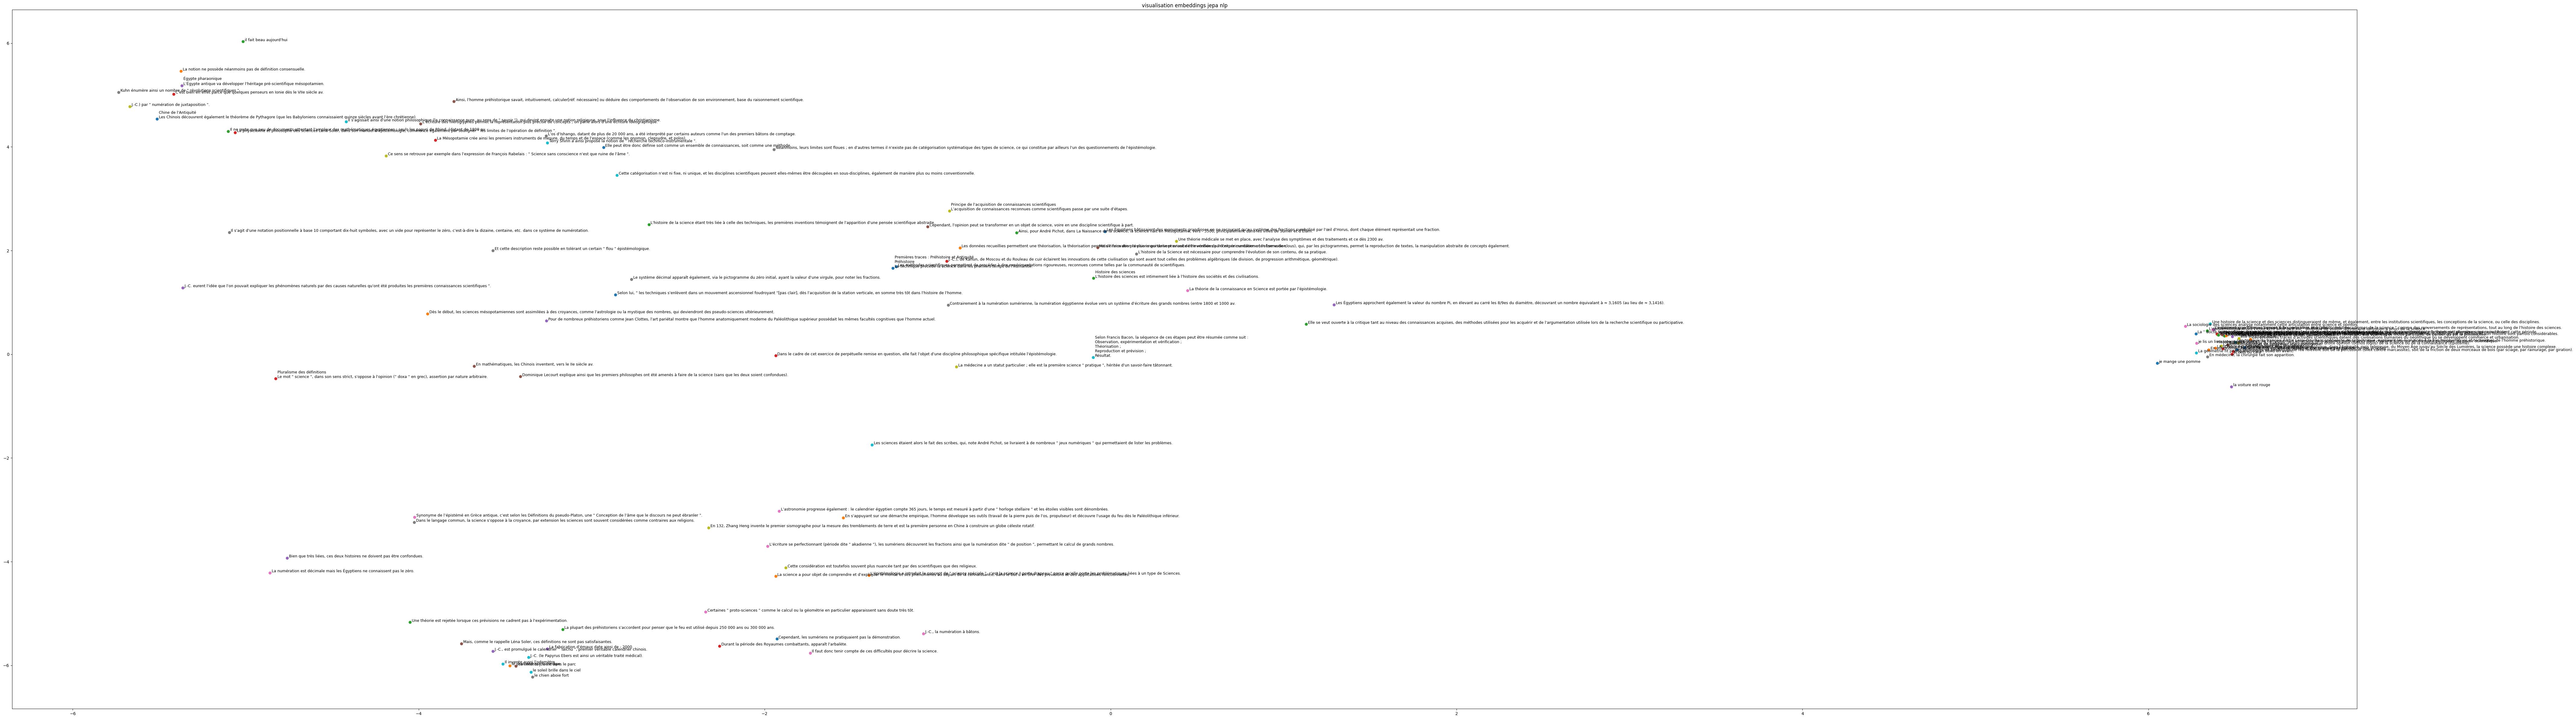

In [ ]:
embeddings = []
labels = []
for i, sent in enumerate(encoded_dataset):
    z = model.encoder_context(sent.unsqueeze(0))
    embeddings.append(z.detach().numpy()[0])
    labels.append(dataset[i]["fr"])
pca = PCA(n_components=2)
emb2d = pca.fit_transform(embeddings)
plt.figure(figsize=(100,30))
for i, txt in enumerate(labels):
    plt.scatter(emb2d[i,0], emb2d[i,1])
    plt.text(emb2d[i,0]+0.01,emb2d[i,1]+0.01, txt, fontsize=9)
    plt.title("visualisation embeddings jepa nlp")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


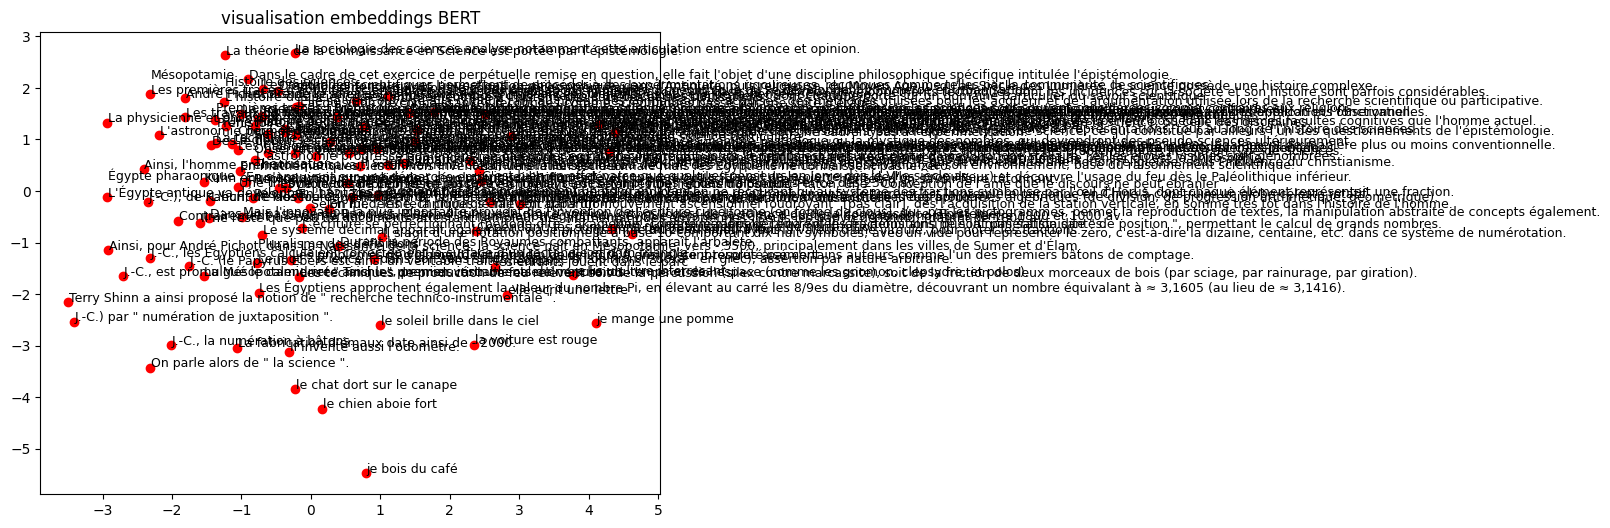

In [ ]:
try:
    from transformers import BertTokenizer, BertModel
    tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
    bert_model = BertModel.from_pretrained("bert-base-uncased")
    bert_embeddings = []
    for item in dataset:
        tokens = tokenizer(item["fr"], return_tensors="pt")
        with torch.no_grad():
            out = bert_model(**tokens)
        bert_embeddings.append(out.last_hidden_state.mean(dim=1).numpy()[0])  # ✅ fix 1 : inden dans le for
    pca_bert = PCA(n_components=2)
    emb2d_bert = pca_bert.fit_transform(bert_embeddings)
    plt.figure(figsize=(8,6))
    for i, txt in enumerate(labels):
        plt.scatter(emb2d_bert[i,0], emb2d_bert[i,1], c="r")
        plt.text(emb2d_bert[i,0]+0.01, emb2d_bert[i,1]+0.01, txt, fontsize=9)
    plt.title("visualisation embeddings BERT")  # ✅ fix 2 : hors du for (inutile de le répéter)
    plt.show()
except Exception as e:
    print(f"transformers non installé ou erreur : {e}")  # ✅ fix 3 : affiche l'erreur réelle

In [ ]:
test_sentence = "je mange une banane"
encoded = encode_sentence(test_sentence).unsqueeze(0)
z = model.encoder_context(encoded)
print(z)

tensor([[-1.2695,  0.5031,  0.7419,  0.7636,  1.1539, -0.0639,  0.4318,  0.7697,
         -0.4685, -0.0070,  0.1585, -0.7811,  0.6844, -0.0363,  0.0587,  0.6249,
         -0.8715,  1.1234,  0.0163,  0.4476,  1.1396,  1.6689, -0.8268,  0.8788,
          0.4783, -0.2530, -0.7449, -0.3808, -1.4422,  1.5104, -0.9552,  0.2459,
          1.2956,  0.4641,  0.8143, -0.8660, -0.8294,  0.1281, -0.1020, -1.1321,
          0.0345, -0.6399, -0.6150, -1.5914, -2.0842, -0.6272, -1.2076, -0.1027,
         -1.1775,  0.0236, -2.7900,  0.5568,  1.6191, -0.6284, -0.6072,  0.3434,
         -0.5150,  1.4696,  0.2702,  2.5135,  0.3930, -0.9125,  0.2727,  1.0546]],
       grad_fn=<MeanBackward1>)


In [ ]:
test_sentence = "je mange une pomme"
encoded = encode_sentence(test_sentence).unsqueeze(0)
z = model.encoder_context(encoded)
print(z)

tensor([[-0.8761,  0.6794,  0.7256,  0.7672,  0.8565, -0.2581,  0.5200,  0.8572,
         -0.7389, -0.0265,  0.1521, -0.6159,  0.7349, -0.0842, -0.0762,  0.5758,
         -0.5720,  1.4570,  0.0357,  0.4415,  0.9214,  1.3727, -0.8160,  0.9565,
          0.4718, -0.2006, -0.7465, -0.3540, -1.0327,  1.5293, -0.6301,  0.2533,
          0.9829,  0.4173,  1.1084, -1.0767, -0.6081,  0.2024, -0.0215, -2.3394,
         -0.0096, -0.6449, -0.5993, -1.5832, -1.5722, -0.5964, -1.2294, -0.1589,
         -1.2474,  0.0089, -2.8055,  0.3118,  2.1105, -0.3318, -0.6725,  0.4354,
         -1.0492,  1.4351,  0.1500,  1.8890,  0.7700, -0.9038,  0.3784,  1.0512]],
       grad_fn=<MeanBackward1>)


In [ ]:
s1 = "je mange une pomme"
s2 = "je mange une banane"

z1 = model.encoder_context(encode_sentence(s1).unsqueeze(0))
z2 = model.encoder_context(encode_sentence(s2).unsqueeze(0))

sim = F.cosine_similarity(z1, z2).item()
print(f"Similarité cosinus : {sim:.4f}")

Similarité cosinus : 0.9756


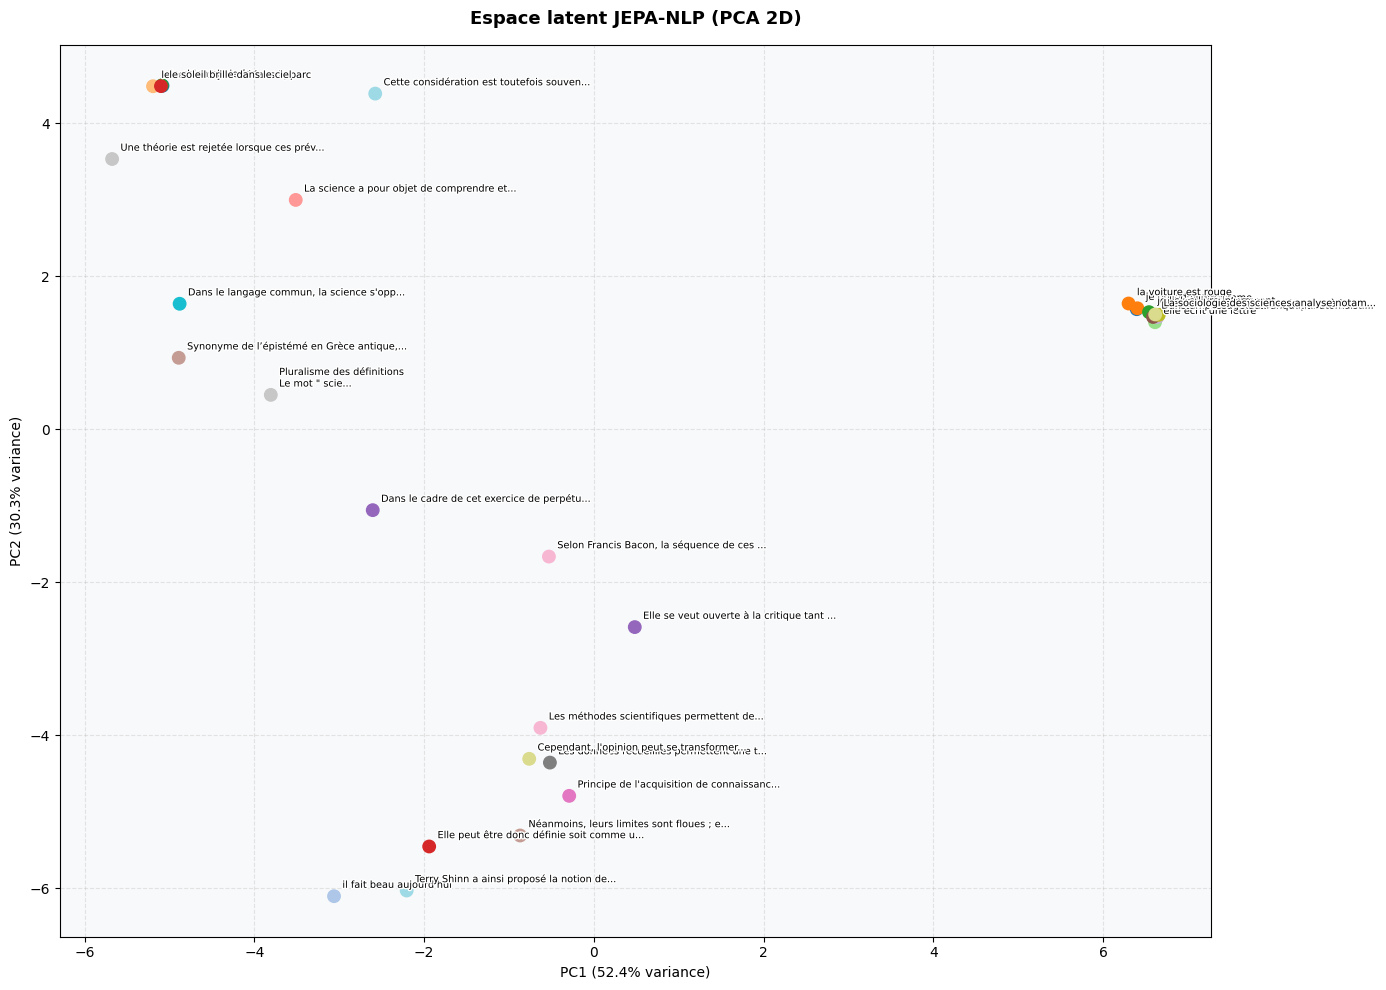

✅ Sauvegardé dans jepa_embeddings.png


In [ ]:
import matplotlib.patheffects as pe


# ─────────────────────────────────────────
# PARAMETRES
# ─────────────────────────────────────────
MAX_PHRASES = 30  # limite le nombre de phrases affichées

phrases = [item["fr"] for item in dataset[:MAX_PHRASES]]

# ─────────────────────────────────────────
# ENCODAGE
# ─────────────────────────────────────────
model.eval()
with torch.no_grad():
    vecteurs = [
        model.encoder_context(encode_sentence(p).unsqueeze(0)).squeeze(0).numpy()
        for p in phrases
    ]

# ─────────────────────────────────────────
# PCA 2D
# ─────────────────────────────────────────
pca = PCA(n_components=2)
coords = pca.fit_transform(vecteurs)

# ─────────────────────────────────────────
# VISUALISATION PROPRE
# ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))  # grand canvas
ax.set_facecolor("#f8f9fa")
fig.patch.set_facecolor("#ffffff")

# Points
scatter = ax.scatter(
    coords[:, 0], coords[:, 1],
    s=80, c=range(len(phrases)),
    cmap="tab20", zorder=3
)

# Labels avec contour blanc pour lisibilité
for i, phrase in enumerate(phrases):
    # Raccourcir le label si trop long
    label = phrase[:40] + "..." if len(phrase) > 40 else phrase
    txt = ax.annotate(
        label,
        (coords[i, 0], coords[i, 1]),
        fontsize=7,
        xytext=(6, 6),
        textcoords="offset points",
        zorder=4
    )
    # Contour blanc derrière le texte → plus lisible
    txt.set_path_effects([
        pe.withStroke(linewidth=2, foreground="white")
    ])

ax.set_title("Espace latent JEPA-NLP (PCA 2D)", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.savefig("jepa_embeddings.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Sauvegardé dans jepa_embeddings.png")

In [ ]:
def similarite(p1, p2):
    model.eval()
    with torch.no_grad():
        z1 = model.encoder_context(encode_sentence(p1).unsqueeze(0))
        z2 = model.encoder_context(encode_sentence(p2).unsqueeze(0))
        score = F.cosine_similarity(z1, z2).item()
    return score
paires = [
    # similaires → score attendu ÉLEVÉ
    ("je mange une pomme",       "je mange une banane"),
    ("le chat dort sur le canape","le chien dort sur le sol"),
    # différentes → score attendu MOYEN
    ("je mange une pomme",       "il fait beau aujourd'hui"),
    # absurdes → score attendu BAS
    ("je mange une pomme",       "le soleil mange une voiture"),
    # contradictoires
    ("le chat dort",             "le chat court vite"),
]

print(f"{'Phrase 1':<30} {'Phrase 2':<30} {'Score':>6}")
print("-" * 70)
for p1, p2 in paires:
    score = similarite(p1, p2)
    emoji = "🟢" if score > 0.8 else "🟡" if score > 0.5 else "🔴"
    print(f"{p1:<30} {p2:<30} {score:>6.3f} {emoji}")

Phrase 1                       Phrase 2                        Score
----------------------------------------------------------------------
je mange une pomme             je mange une banane             0.999 🟢
le chat dort sur le canape     le chien dort sur le sol        0.902 🟢
je mange une pomme             il fait beau aujourd'hui       -0.443 🔴
je mange une pomme             le soleil mange une voiture     0.105 🔴
le chat dort                   le chat court vite              0.942 🟢


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Sauvegarder le modèle
torch.save(model.state_dict(), '/content/drive/MyDrive/jepa_model.pth')

# Recharger plus tard
model.load_state_dict(torch.load('/content/drive/MyDrive/jepa_model.pth'))

Mounted at /content/drive


<All keys matched successfully>